## 3.6.2 Cazzaro and Pisinger 2022 G-140 and G-210

**Concepts:** [Exact optimization](../routers.md#exact-optimization)

This is used in the paper **Flexible cable routing framework for wind farm collection system optimization**.

In [1]:
import pickle
from importlib.resources import files

In [2]:
from optiwindnet.interarraylib import G_from_S
from optiwindnet.svg import svgplot
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.importer import L_from_yaml
from optiwindnet.pathfinding import PathFinder
from optiwindnet.MILP import solver_factory, ModelOptions
from optiwindnet.interarraylib import as_normalized

### Reference solutions

Cazzaro, D., & Pisinger, D. (2022). Balanced cable routing for offshore wind farms with obstacles. Networks, 80(4), 386–406. https://doi.org/10.1002/net.22100

In [3]:
G140_ref = pickle.load(open('data/cazzaro_2022G_140_paper_routeset.pkl', 'rb'))

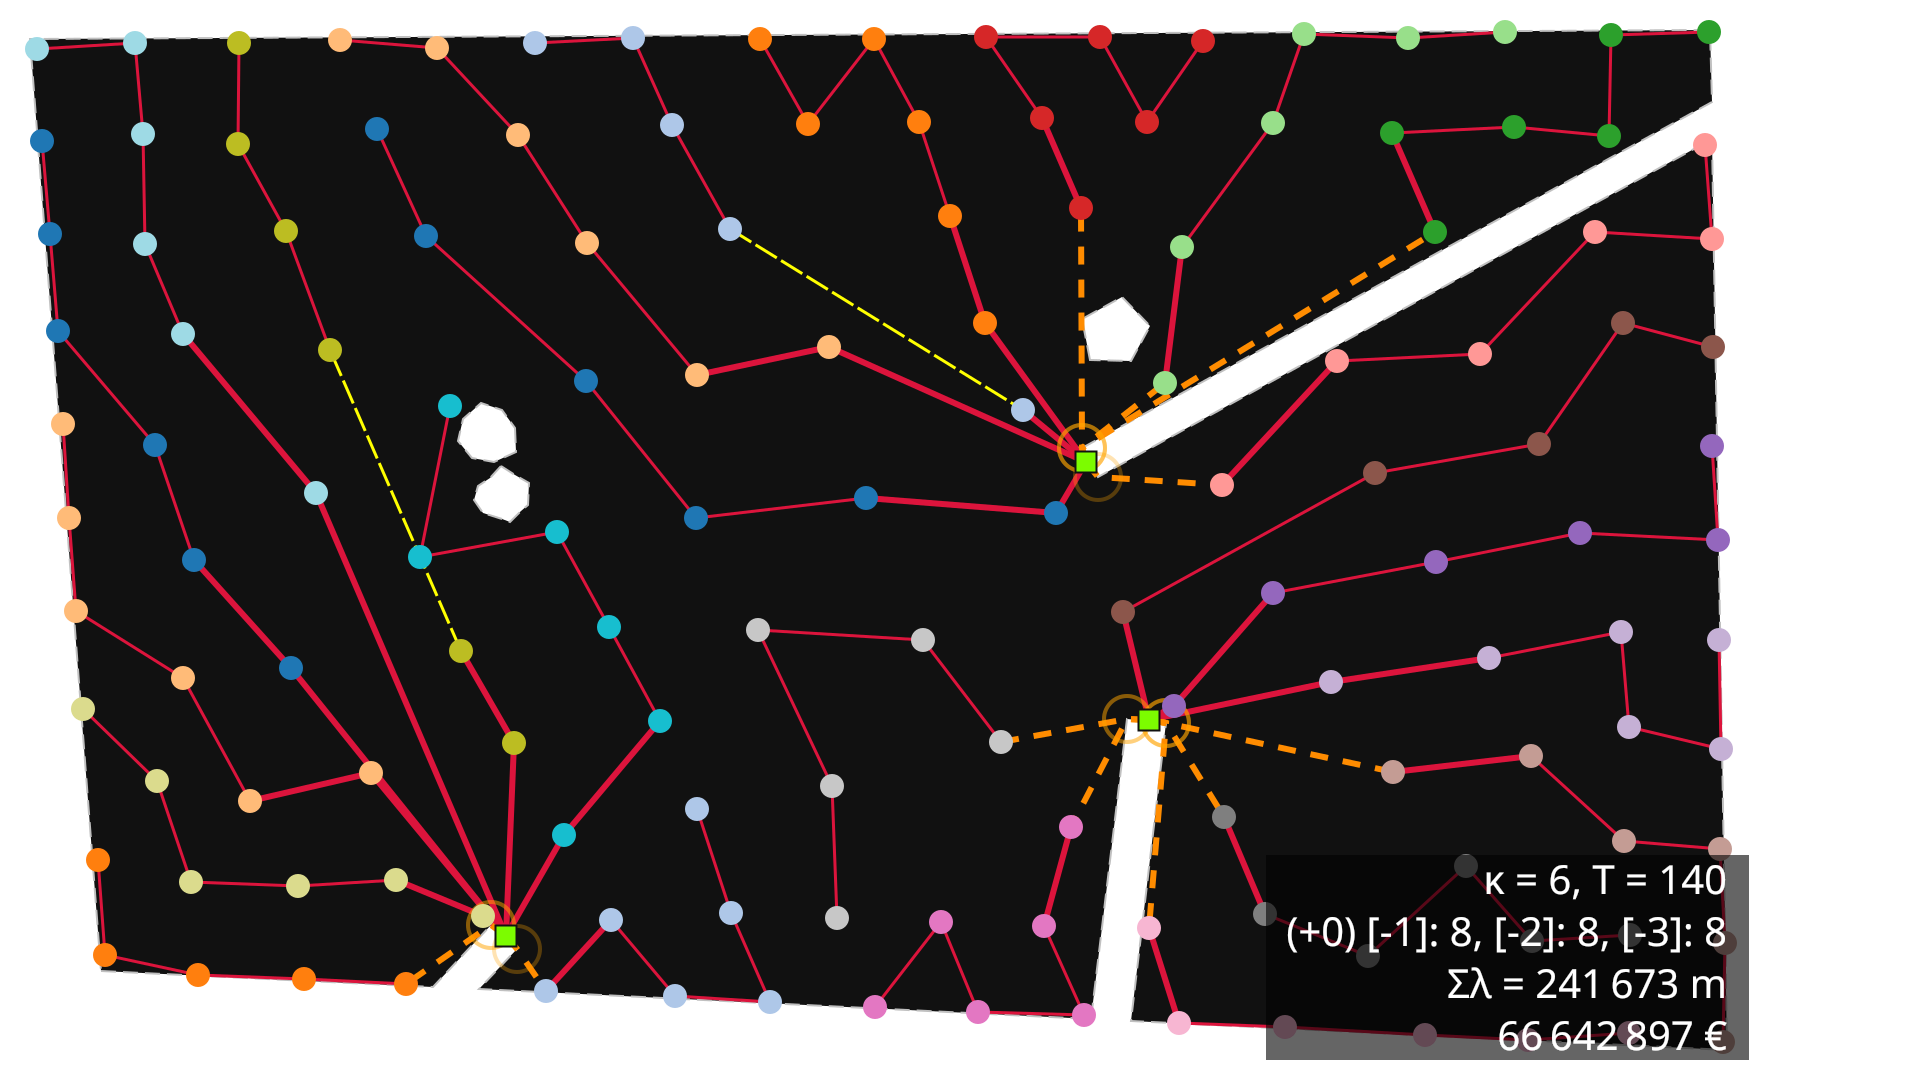

In [4]:
svgplot(G140_ref)

In [5]:
G210_ref = pickle.load(open('data/cazzaro_2022G_210_paper_routeset.pkl', 'rb'))

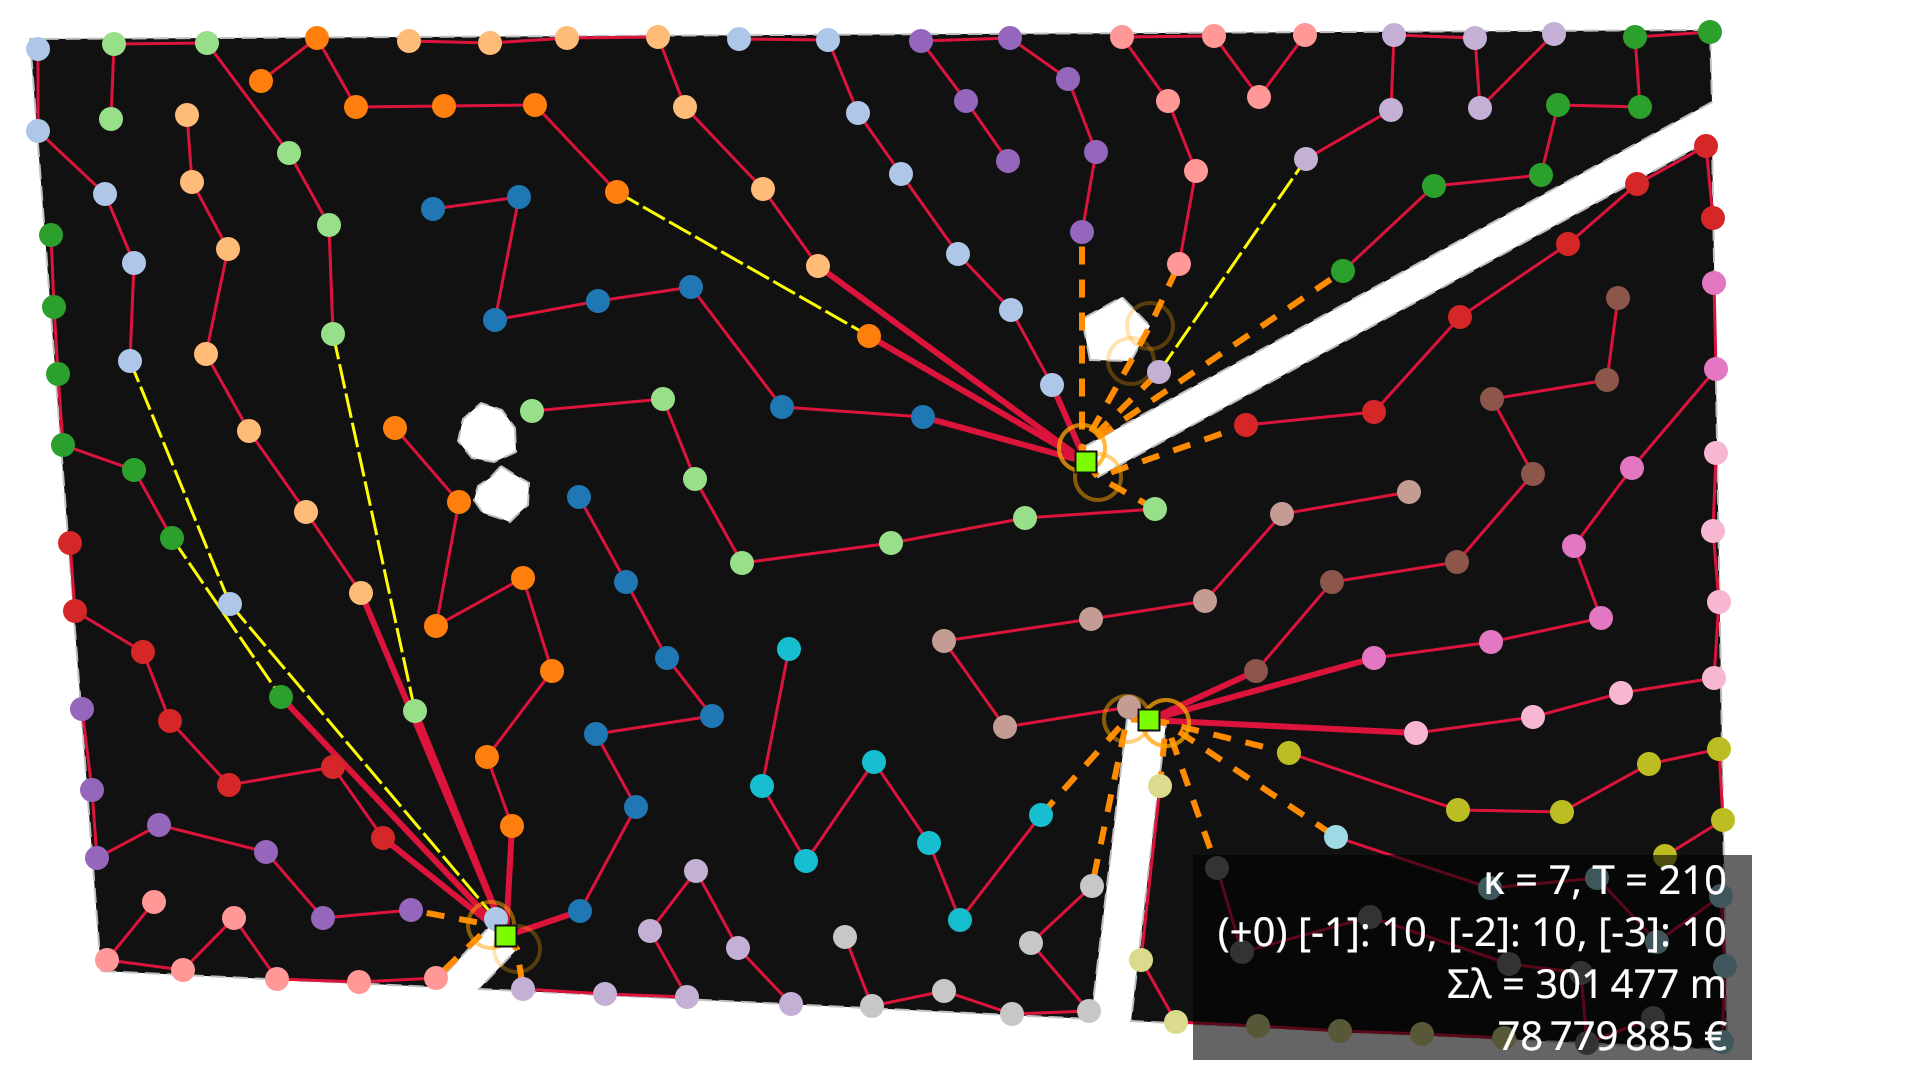

In [6]:
svgplot(G210_ref)

### Start here

### Instantiate solver

In [7]:
solver = solver_factory('gurobi')

### G-140, κ = 6

In [8]:
L140 = L_from_yaml(files('optiwindnet.data') / 'Cazzaro-2022G-140.yaml')

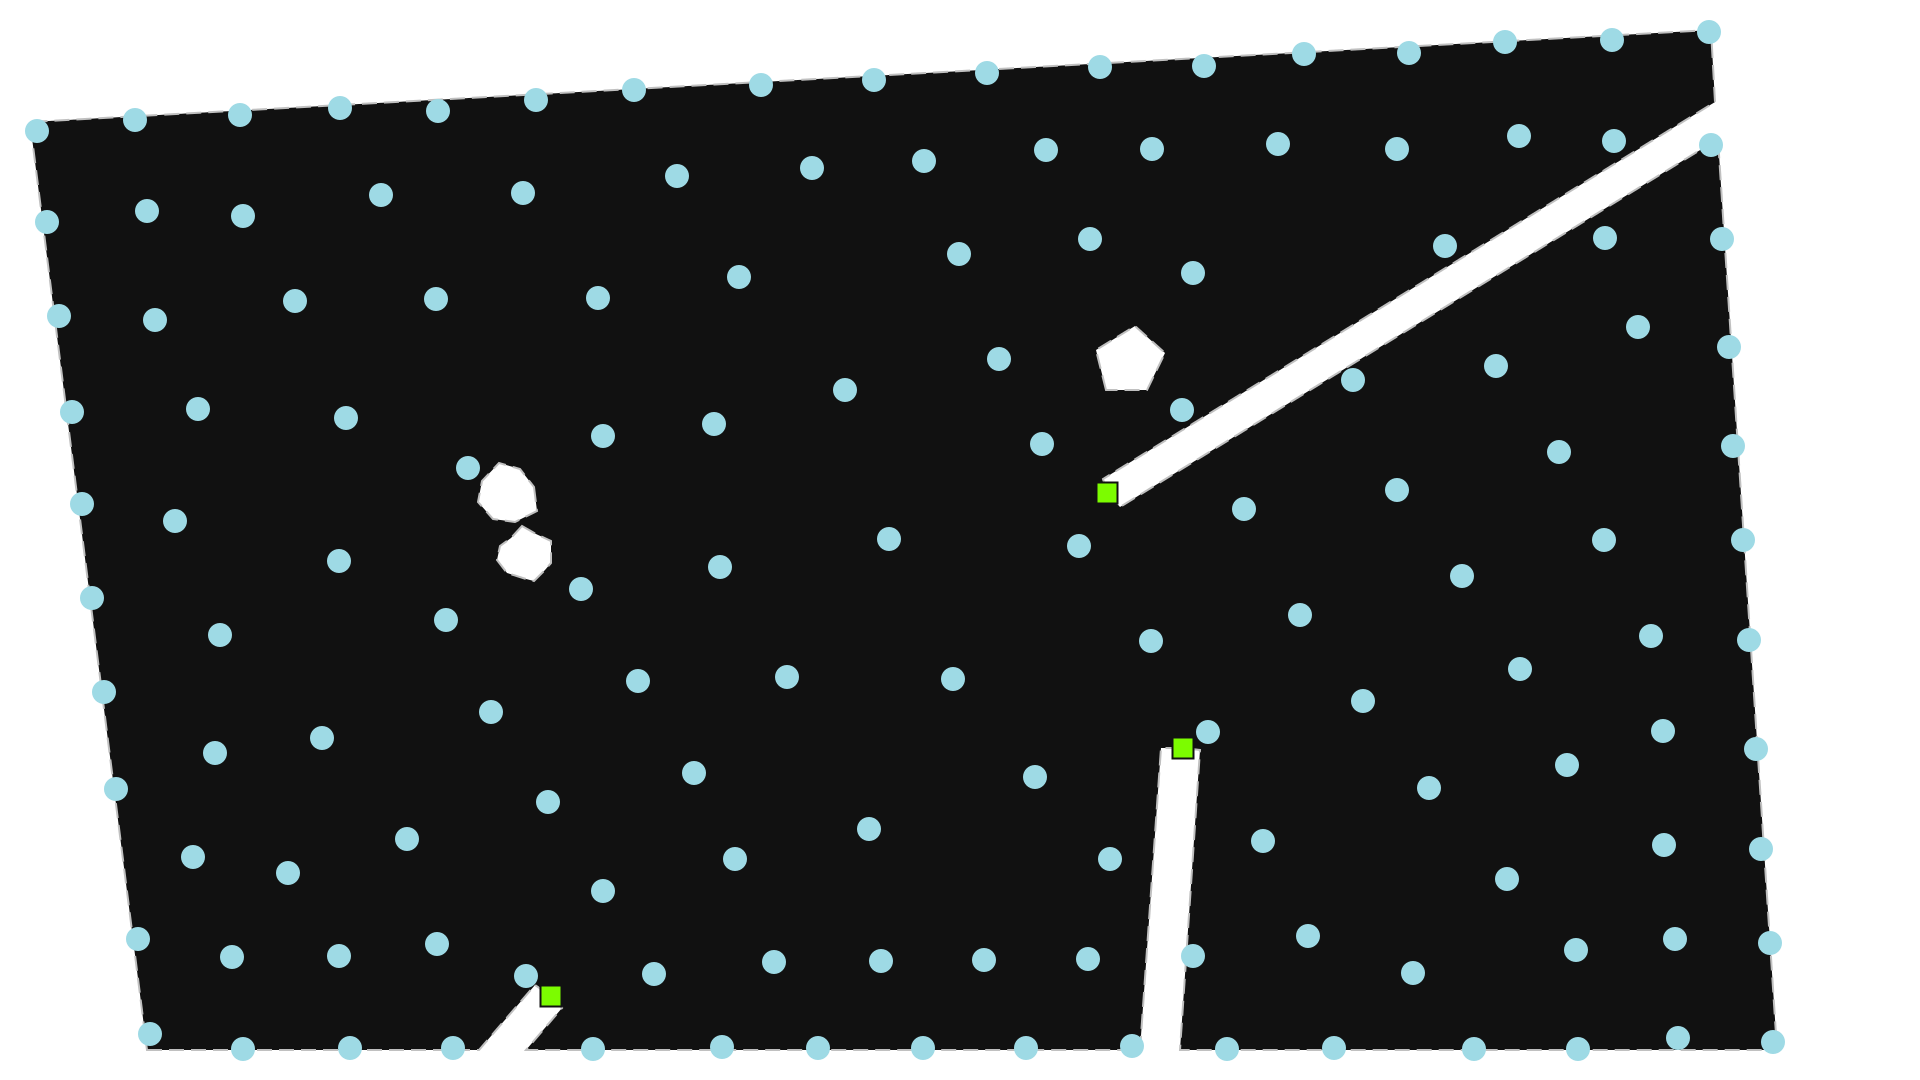

In [9]:
svgplot(L140)

In [10]:
P, A = make_planar_embedding(L140)
A_norm = as_normalized(A)

In [11]:
Sʹ = hgs_cvrp(A_norm, capacity=6, time_limit=0.5, balanced=True)
Sʹ.graph['solution_time']

(0.19, 0.15, 0.18)

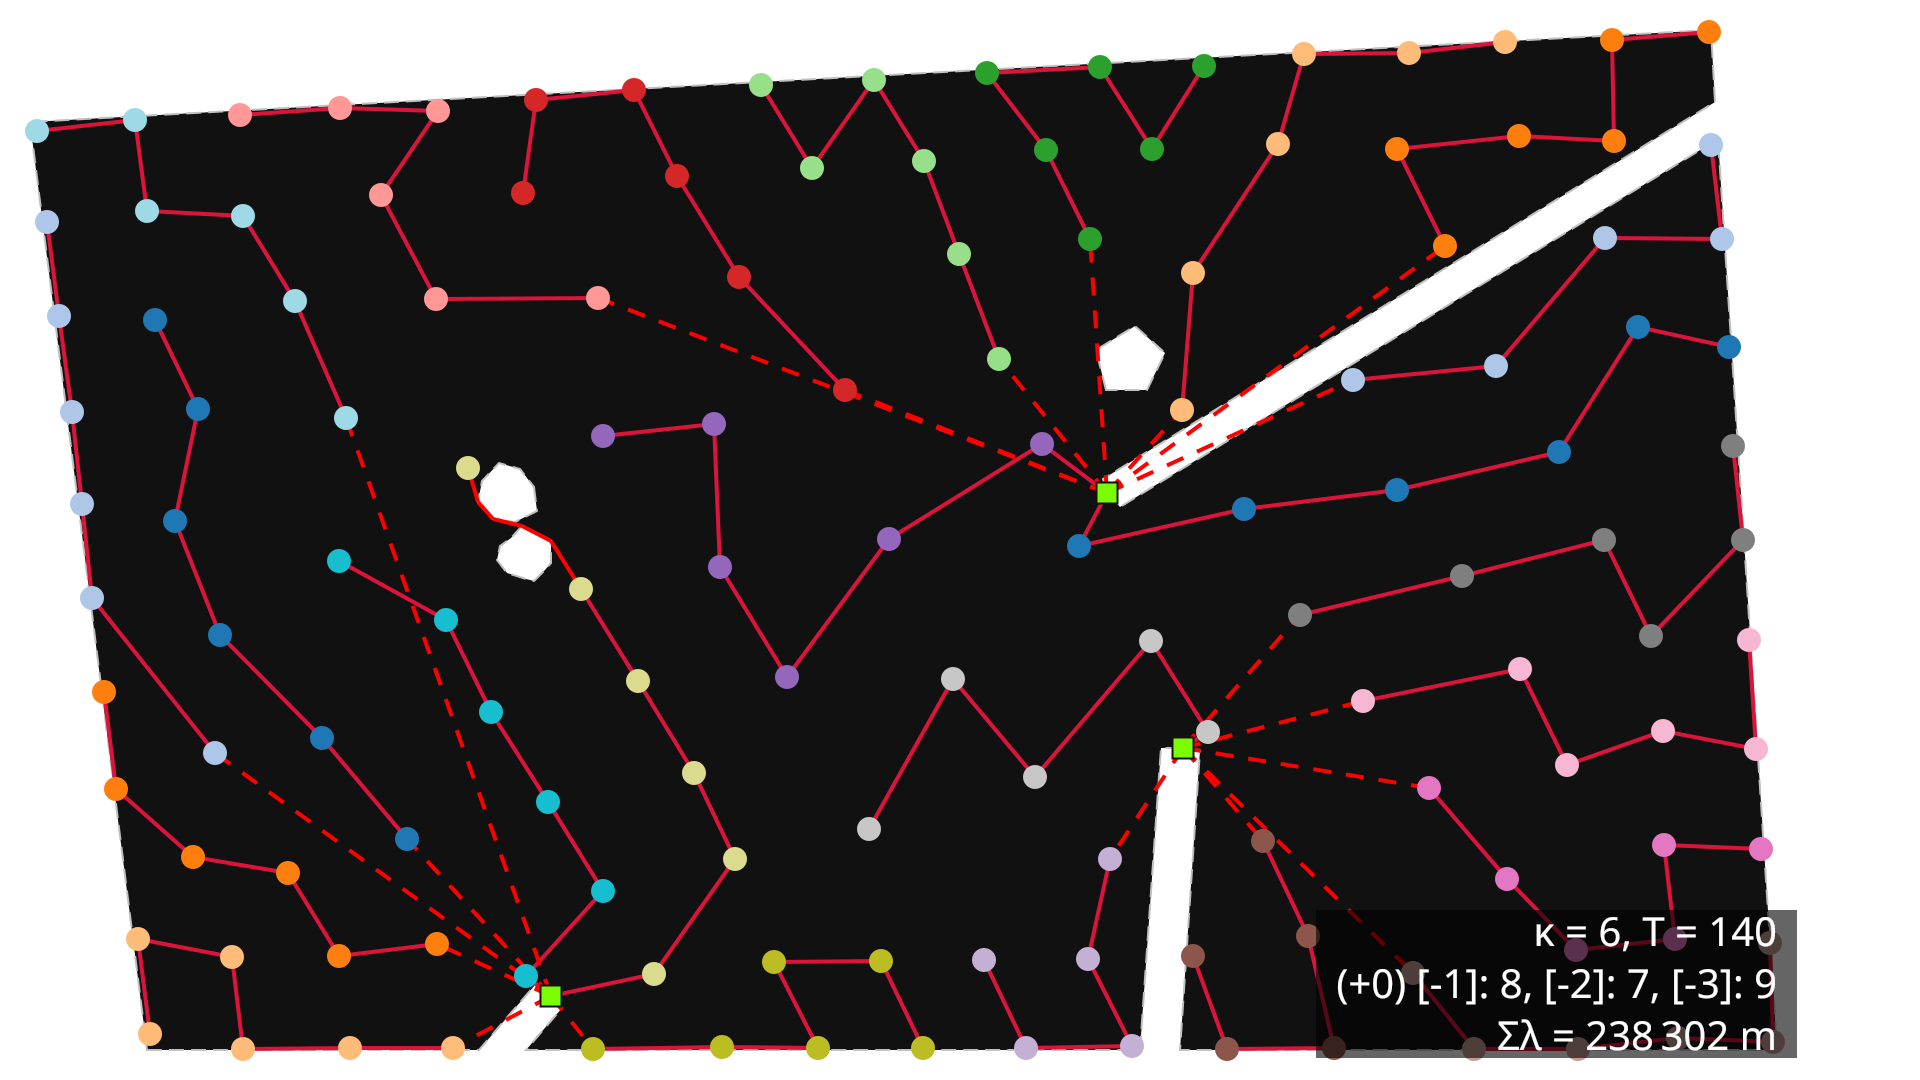

In [12]:
Gʹ = G_from_S(Sʹ, A)
svgplot(Gʹ)

In [13]:
[[Sʹ[r][n]['load'] for n in Sʹ[r]] for r in range(-3, 0)]

[[6, 5, 6, 6, 6, 6, 6, 6, 6], [5, 5, 6, 6, 6, 6, 5], [6, 6, 6, 6, 6, 6, 6, 6]]

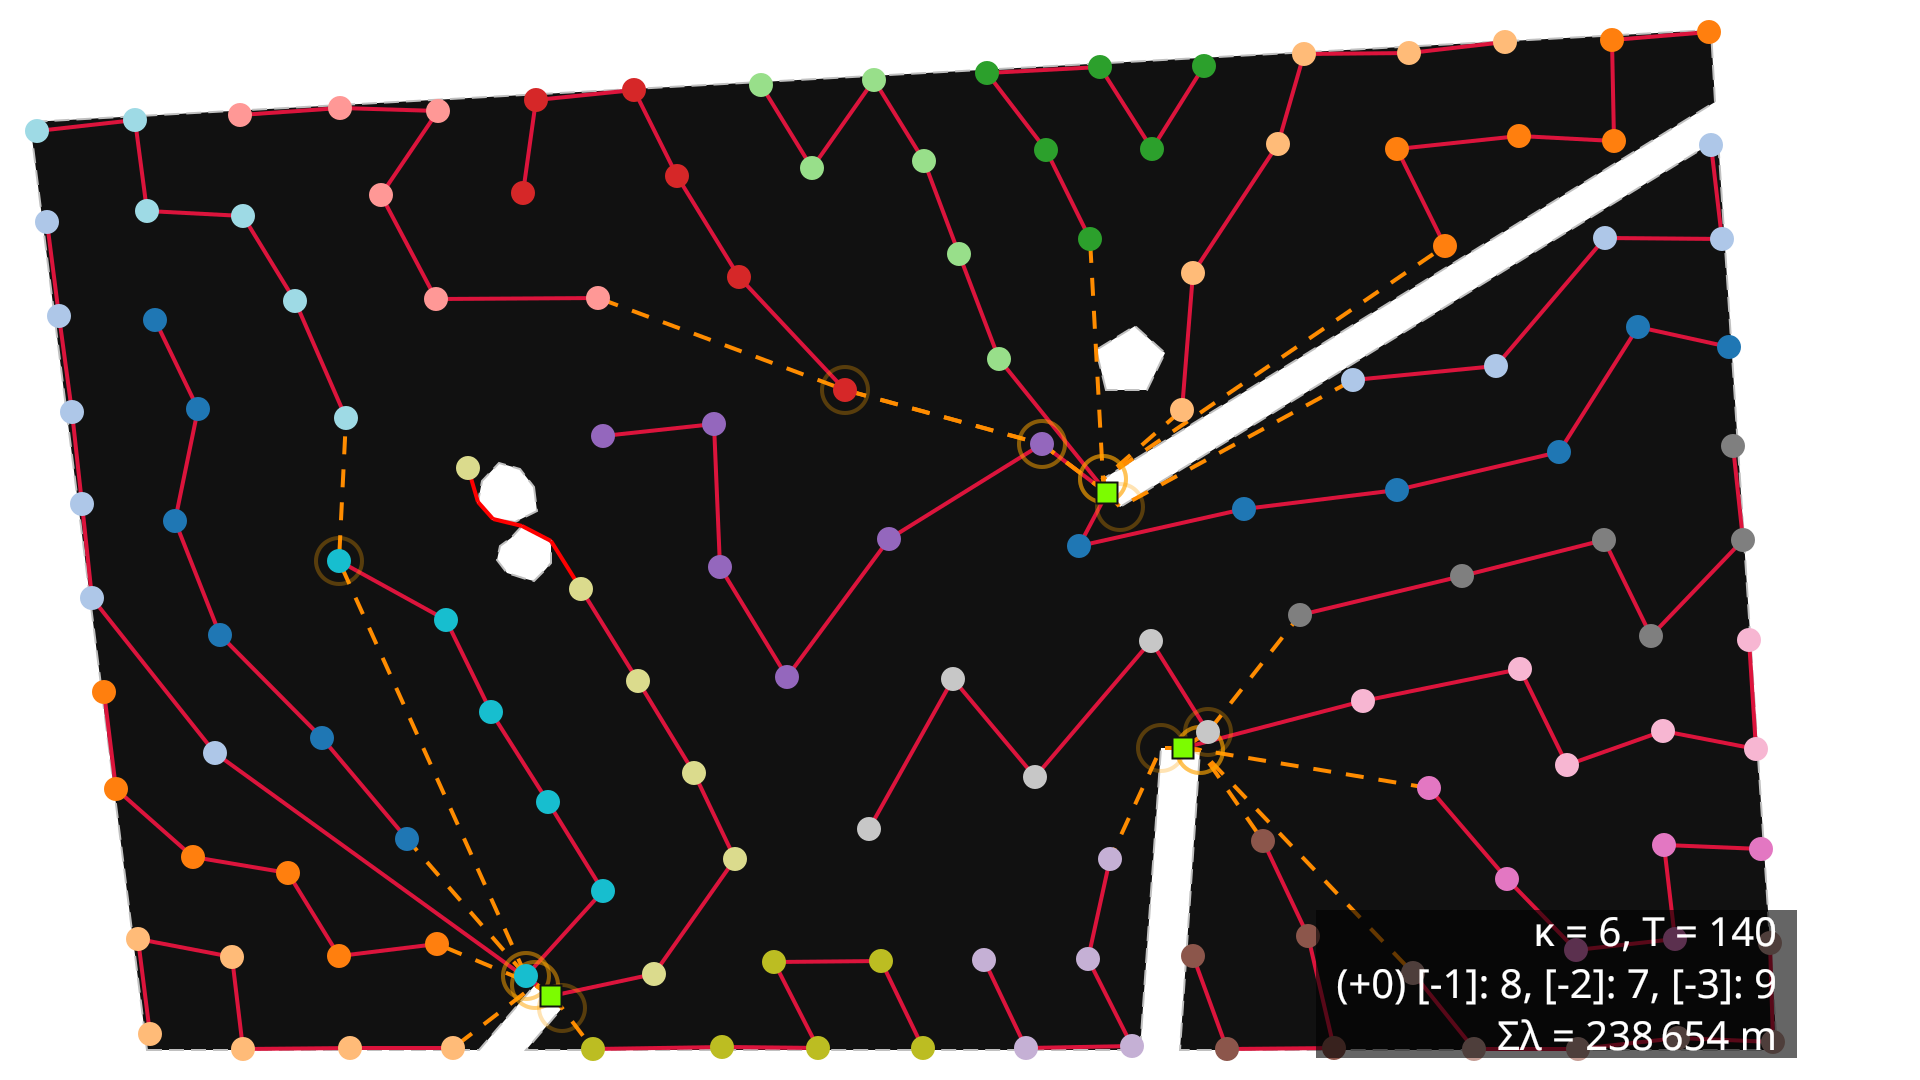

In [14]:
Hʹ = PathFinder(Gʹ, planar=P, A=A).create_detours()
svgplot(Hʹ)

In [15]:
Hʹ.size(weight='length')/G140_ref.size(weight='length') - 1

-0.012491315966834504

In [16]:
solver.set_problem(
    P, A,
    capacity=Sʹ.graph['capacity'],
    model_options=ModelOptions(
        topology="radial",
        feeder_route="segmented",
        feeder_limit="minimum",
        balanced=True,
    ),
    warmstart=Sʹ,
)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk


In [17]:
solver.solve(
    mip_gap=0.005,
    time_limit=10,
    verbose=True,
    options=dict(
        mipfocus=1,
    ),
)

Set parameter TimeLimit to value 10
Set parameter MIPGap to value 0.005
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Debian GNU/Linux forky/sid")

CPU model: 11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  10
MIPGap  0.005
MIPFocus  1

Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Optimize a model with 5391 rows, 3328 columns and 20386 nonzeros (Min)
Model fingerprint: 0x3f19b116
Model has 1664 linear objective coefficients
Variable types: 1664 continuous, 1664 integer (1664 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [4e+02, 2e+04]
  Bounds range     [1e+00, 6e+00]
  RHS range        [1e+00, 1e+02]

Loaded user MIP start with objective 238302

Presolve removed 951 rows and 0 columns
Presolve time: 0.03s
Presolved: 4440 rows, 3328 columns, 180

SolutionInfo(runtime=10.013020992279053, bound=228105.98475989103, objective=235950.71262742073, relgap=0.03324731584903906, termination='maxTimeLimit')

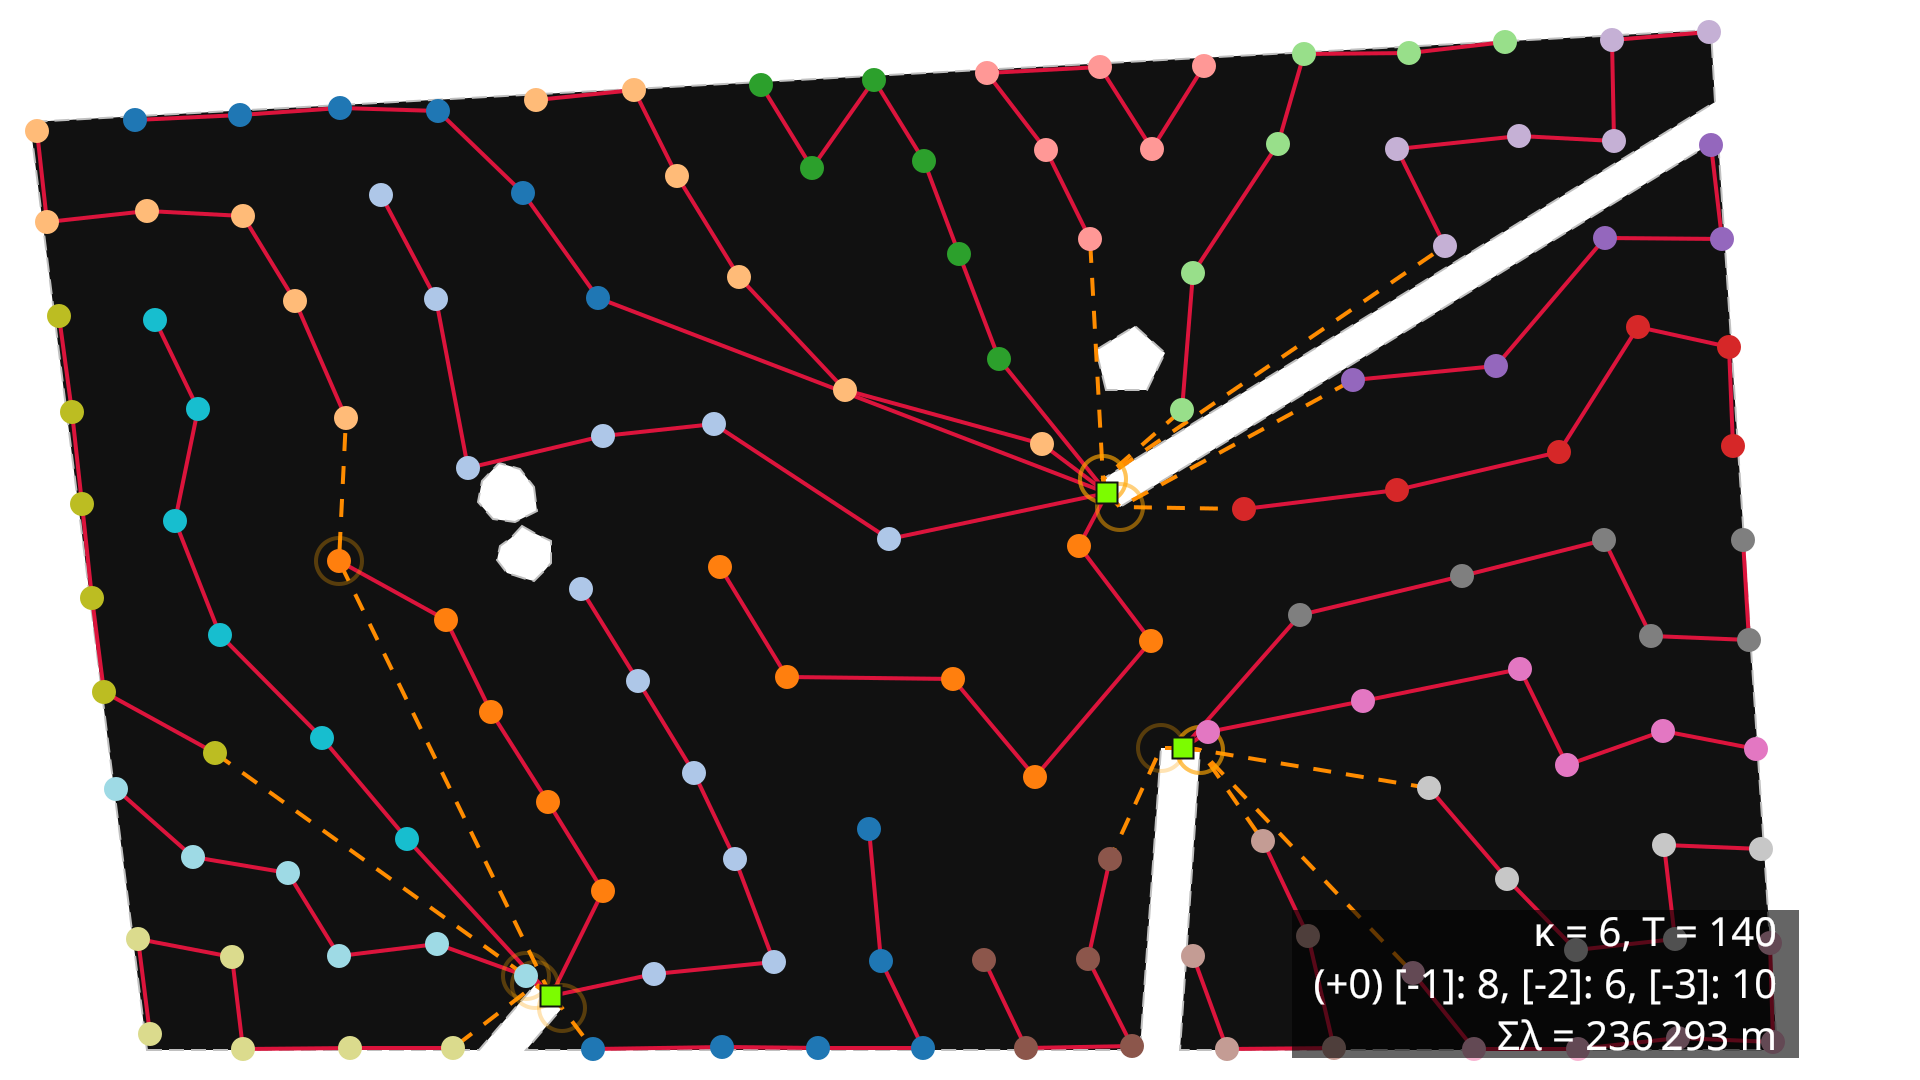

In [18]:
S140, G140 = solver.get_solution()
svgplot(G140)

In [19]:
[[G140[r][n]['load'] for n in G140[r]] for r in range(-3, 0)]

[[6, 6, 6, 6, 6, 6, 6, 5, 6, 6], [6, 6, 6, 5, 5, 6], [6, 5, 6, 6, 6, 6, 6, 6]]

In [20]:
1 - G140.size(weight='length')/G140_ref.size(weight='length')

0.022262590107747227

In [21]:
pickle.dump(G140, open('cazzaro_2022G_140_κ_6_radial_balanced_our.pkl', 'wb'))

### G-210, κ = 7

In [22]:
L210 = L_from_yaml(files('optiwindnet.data') / 'Cazzaro-2022G-210.yaml')

In [23]:
P, A = make_planar_embedding(L210)
A_norm = as_normalized(A)

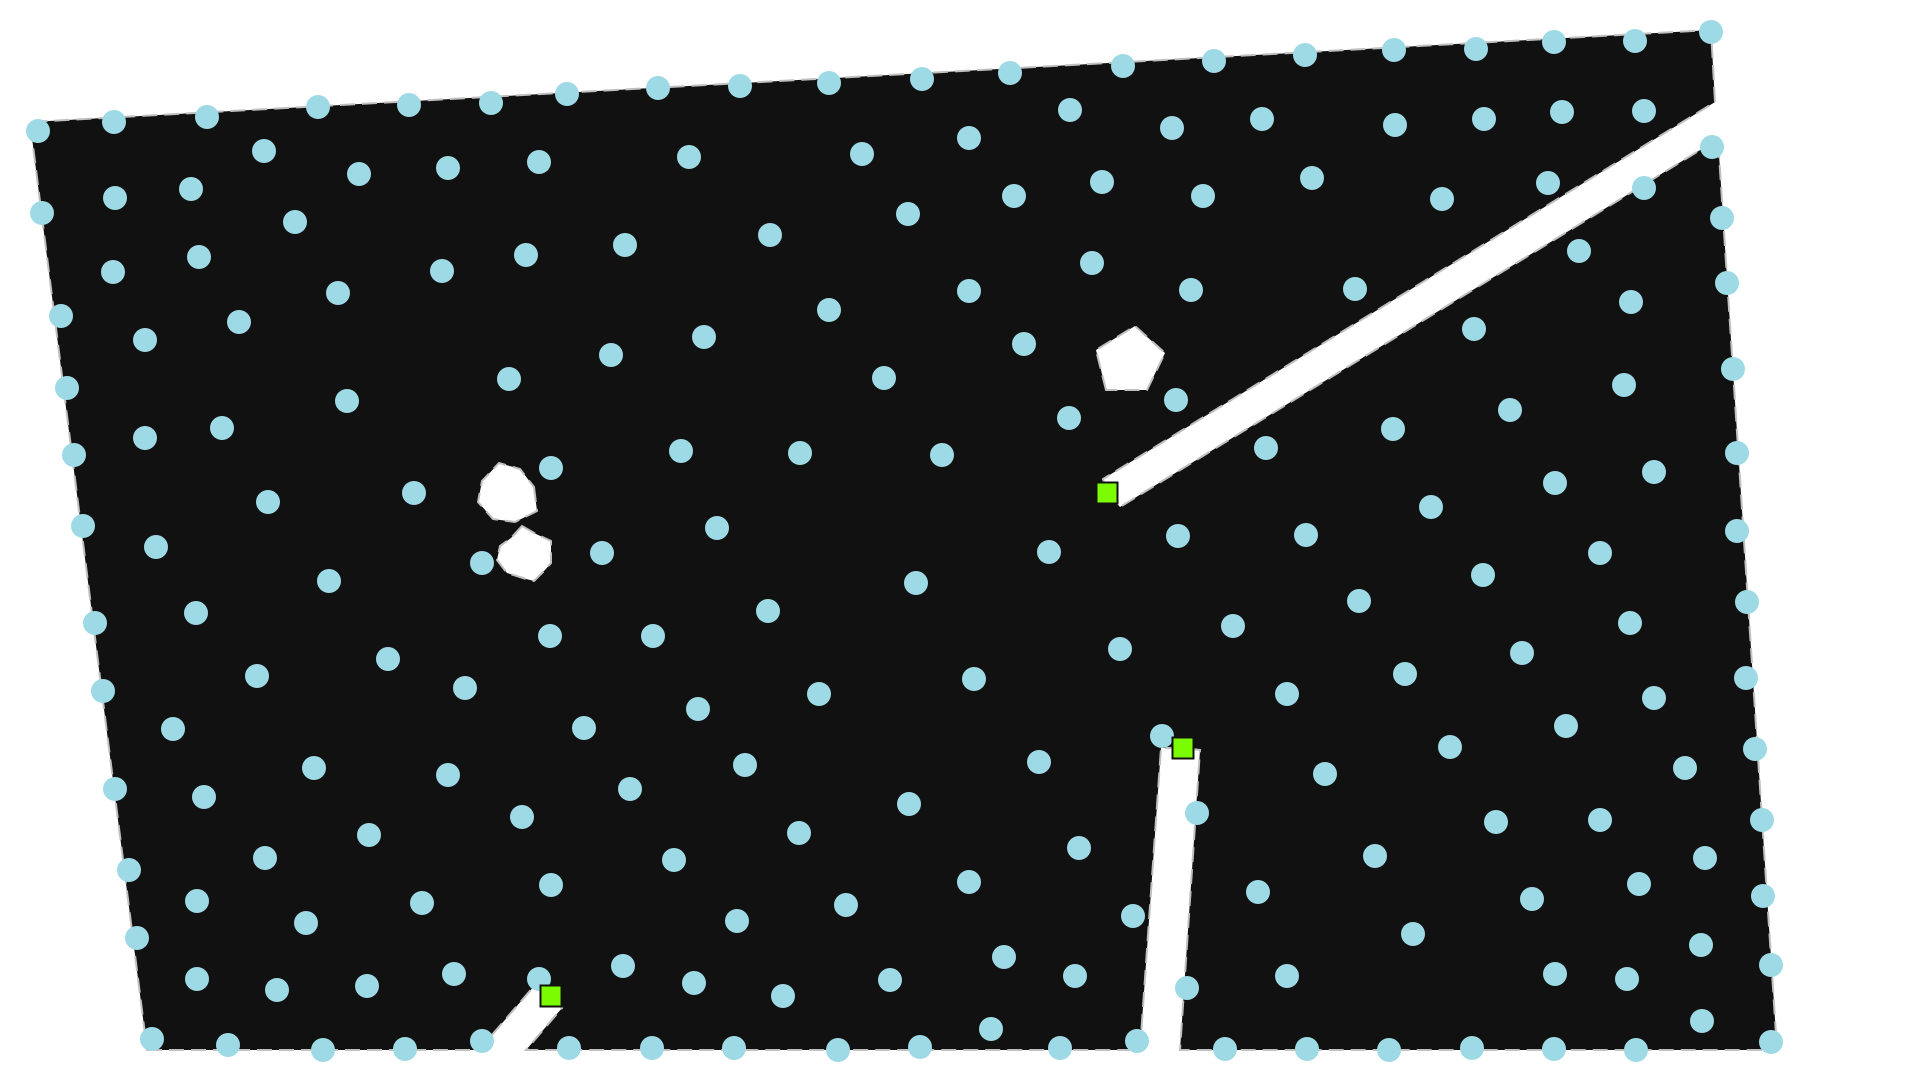

In [24]:
svgplot(L210)

In [25]:
Sʹ = hgs_cvrp(A_norm, capacity=7, time_limit=1, balanced=True)
Sʹ.graph['solution_time']

(0.47, 0.19, 0.49)

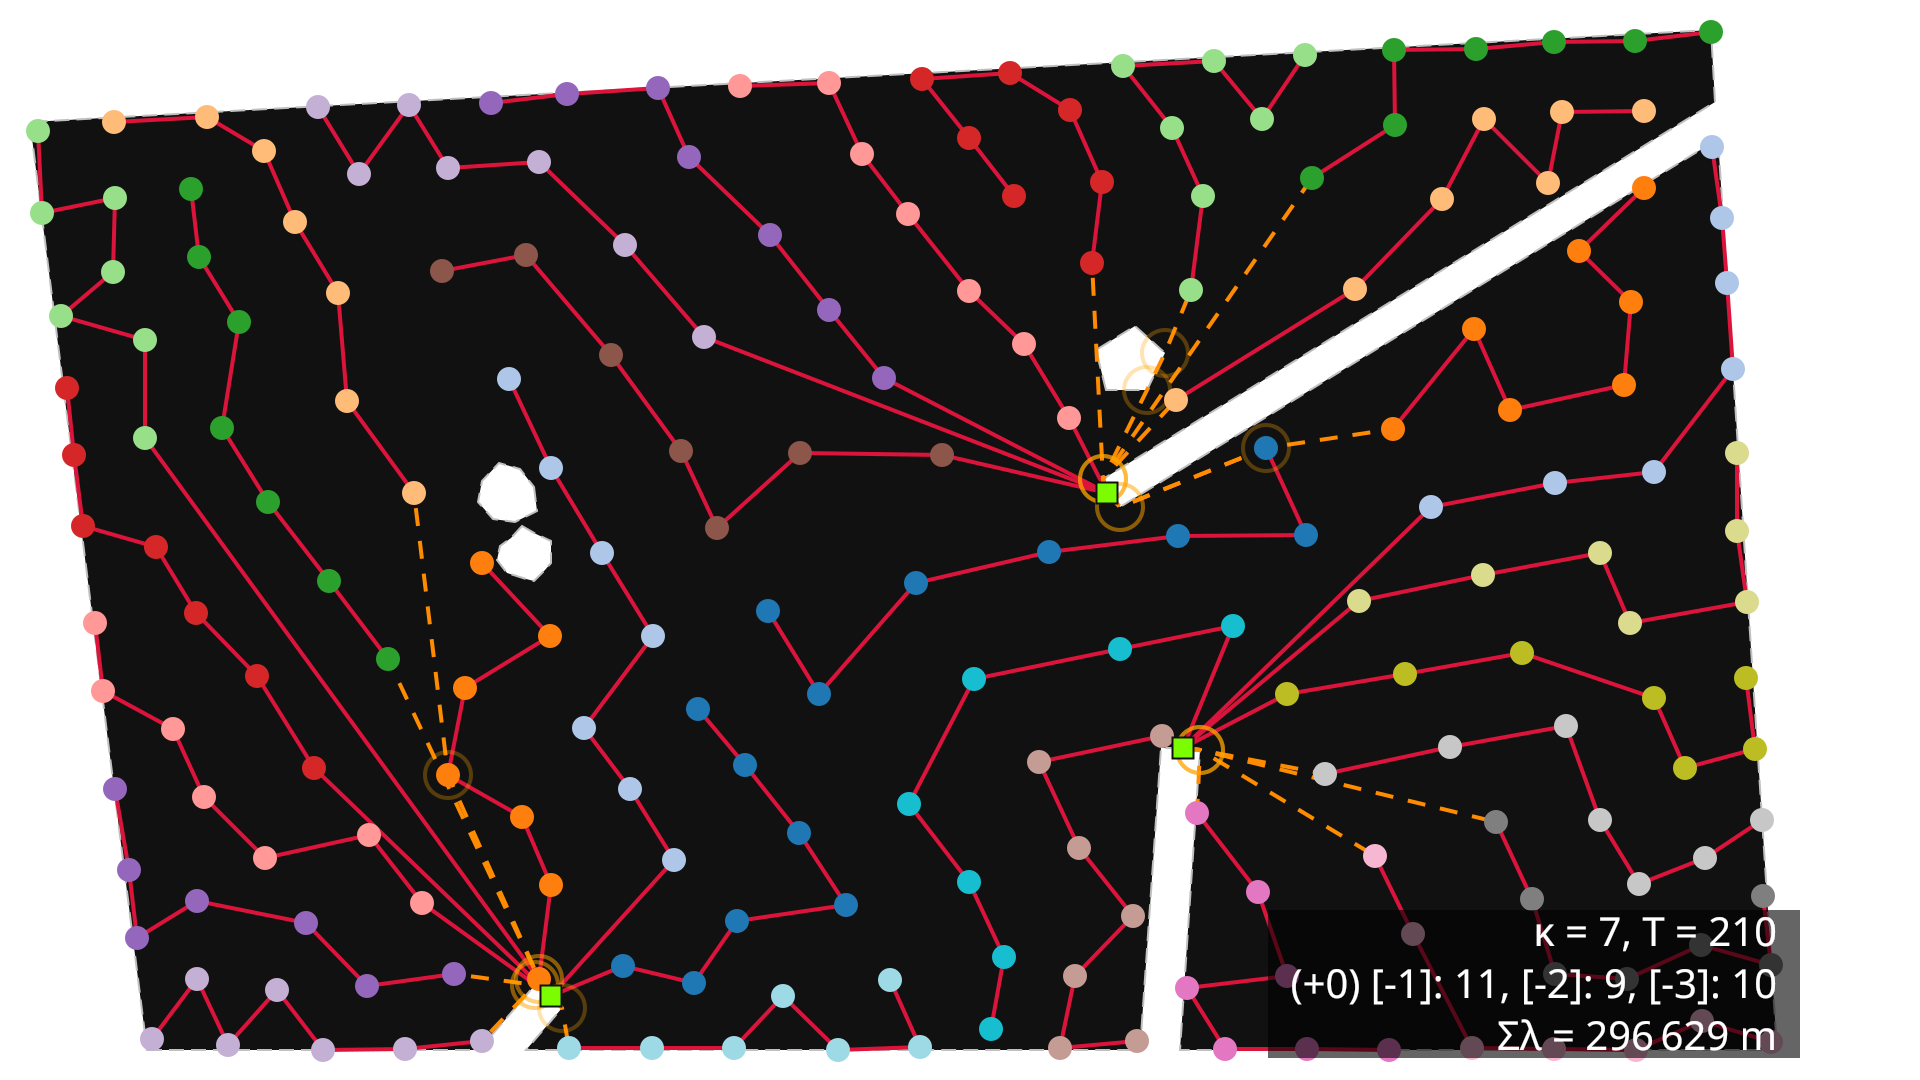

In [26]:
Gʹ = G_from_S(Sʹ, A)
Hʹ = PathFinder(Gʹ, planar=P, A=A).create_detours()
svgplot(Hʹ)

In [27]:
1- Hʹ.size(weight='length')/G210_ref.size(weight='length')

0.016080868449454444

#### Solve the balanced MILP model

In [28]:
solver.set_problem(
    P, A,
    capacity=Sʹ.graph['capacity'],
    model_options=ModelOptions(
        topology="radial",
        feeder_route="segmented",
        feeder_limit="minimum",
        balanced=True,
    ),
    warmstart=Sʹ,
)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk


In [29]:
solver.solve(
    mip_gap=0.005,
    time_limit=95,
    verbose=True,
    options=dict(
        mipfocus=1,
    ),
)

Set parameter TimeLimit to value 95
Set parameter MIPGap to value 0.005
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Debian GNU/Linux forky/sid")

CPU model: 11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  95
MIPGap  0.005
MIPFocus  1

Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Optimize a model with 8414 rows, 5212 columns and 32072 nonzeros (Min)
Model fingerprint: 0xc3784f4d
Model has 2606 linear objective coefficients
Variable types: 2606 continuous, 2606 integer (2606 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+00]
  Objective range  [3e+02, 2e+04]
  Bounds range     [1e+00, 7e+00]
  RHS range        [1e+00, 2e+02]

Loaded user MIP start with objective 296300

Presolve removed 2751 rows and 1050 columns
Presolve time: 0.05s
Presolved: 5663 rows, 4162 columns,

SolutionInfo(runtime=95.01575183868408, bound=280153.8859256094, objective=293441.7483556479, relgap=0.04528279464152385, termination='maxTimeLimit')

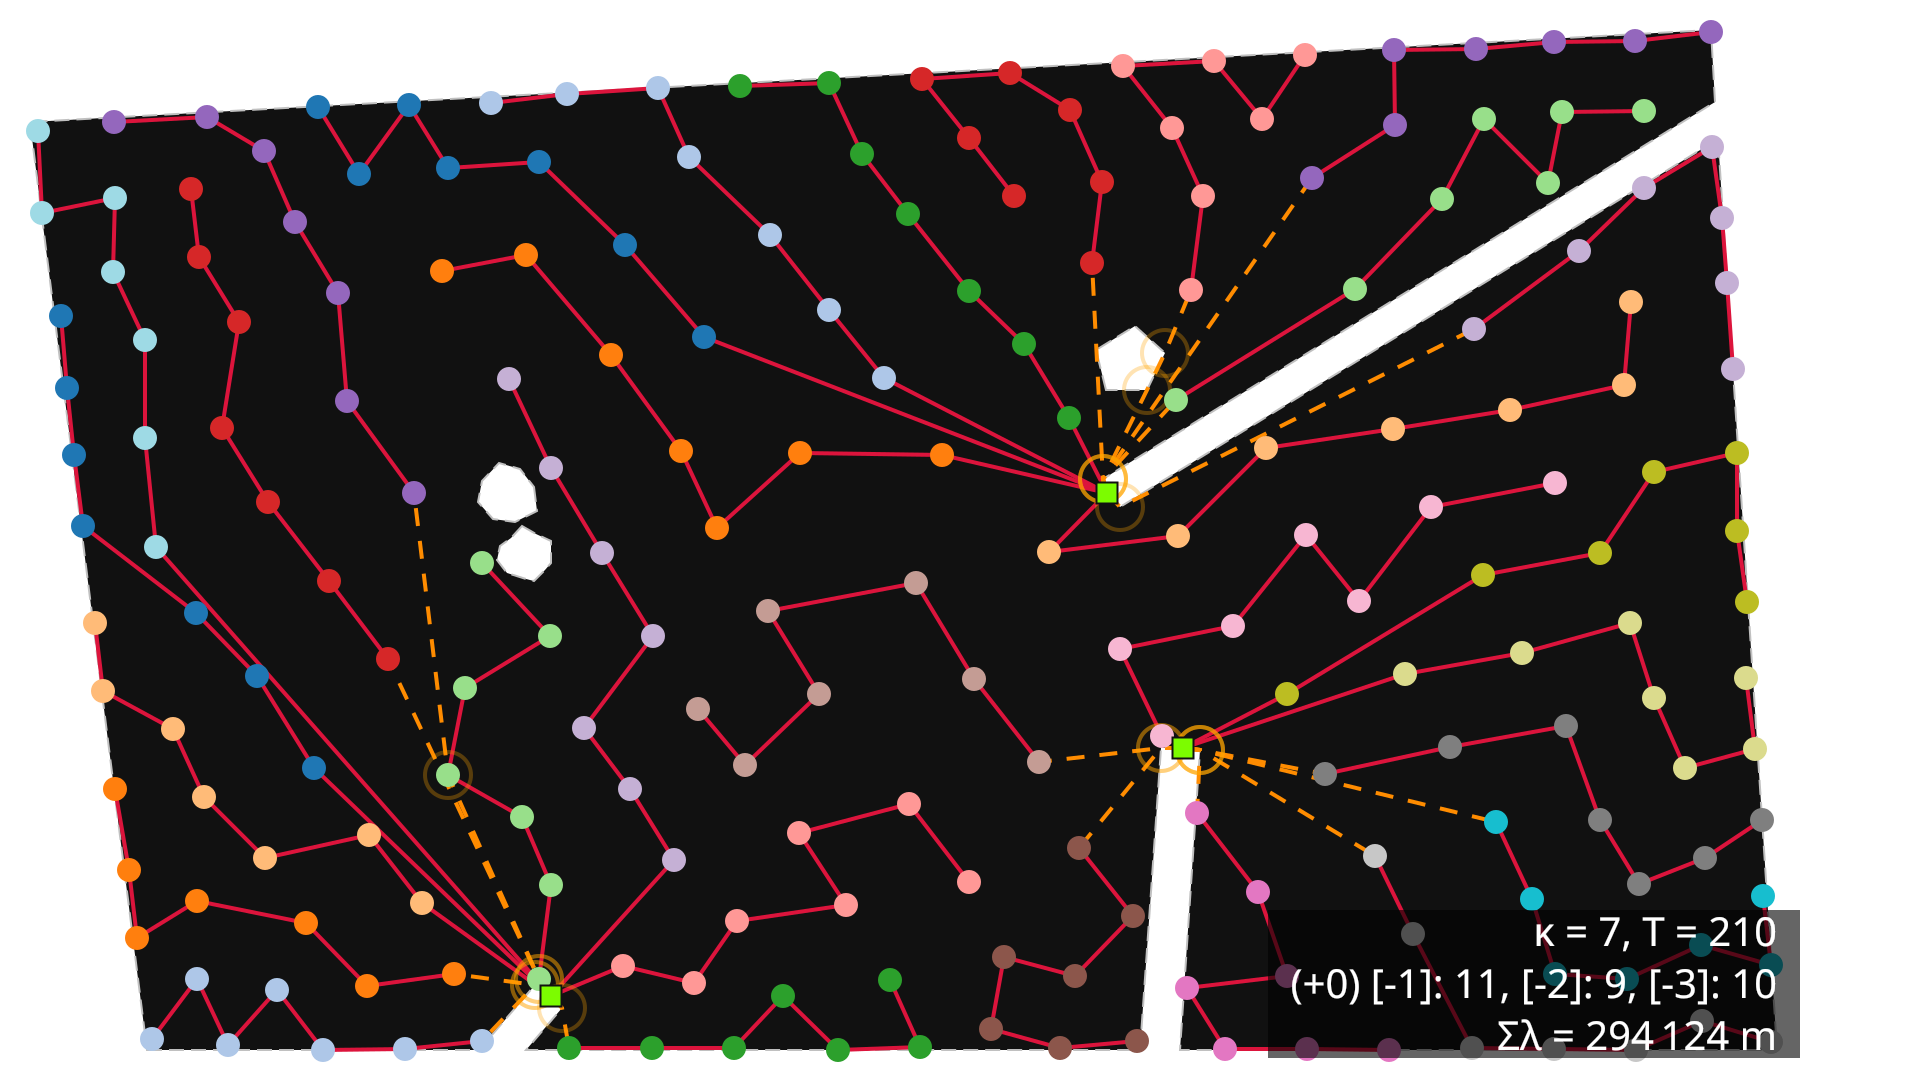

In [30]:
S210, G210 = solver.get_solution()
svgplot(G210)

In [31]:
1 - G210.size(weight='length')/G210_ref.size(weight='length')

0.02439164822108153

In [32]:
pickle.dump(G210, open('cazzaro_2022G_210_κ_7_radial_balanced_our.pkl', 'wb'))